In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('HR_Analytics.csv')
df.head()

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [2]:
df.shape

(1480, 38)

In [3]:
df.columns

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab',
       'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

In [6]:
df.isnull().sum().sort_values(ascending = False)

YearsWithCurrManager        57
EmpID                        0
AgeGroup                     0
Attrition                    0
BusinessTravel               0
Age                          0
DailyRate                    0
Department                   0
Education                    0
DistanceFromHome             0
EmployeeCount                0
EmployeeNumber               0
EnvironmentSatisfaction      0
EducationField               0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction              0
MaritalStatus                0
MonthlyIncome                0
Gender                       0
SalarySlab                   0
MonthlyRate                  0
Over18                       0
NumCompaniesWorked           0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction     0
OverTime                     0
StandardHours                0
StockOptionLevel             0
Training

In [8]:
(df.isnull().sum().sort_values(ascending = False) / len(df) * 100 ).round(2)

YearsWithCurrManager        3.85
EmpID                       0.00
AgeGroup                    0.00
Attrition                   0.00
BusinessTravel              0.00
Age                         0.00
DailyRate                   0.00
Department                  0.00
Education                   0.00
DistanceFromHome            0.00
EmployeeCount               0.00
EmployeeNumber              0.00
EnvironmentSatisfaction     0.00
EducationField              0.00
HourlyRate                  0.00
JobInvolvement              0.00
JobLevel                    0.00
JobRole                     0.00
JobSatisfaction             0.00
MaritalStatus               0.00
MonthlyIncome               0.00
Gender                      0.00
SalarySlab                  0.00
MonthlyRate                 0.00
Over18                      0.00
NumCompaniesWorked          0.00
PercentSalaryHike           0.00
PerformanceRating           0.00
RelationshipSatisfaction    0.00
OverTime                    0.00
StandardHo

In [14]:
(df.isnull().sum() > 0)[df.isnull().sum() > 0].index

Index(['YearsWithCurrManager'], dtype='object')

In [17]:
missing = df.isnull().sum() 
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending = False).round(2)
df_missing = pd.DataFrame({"Missing" : missing , "Missing Percentage" : missing_percentage})
df_missing.sort_values(ascending = False , by =  'Missing Percentage')


,Missing,Missing Percentage
YearsWithCurrManager,57,3.85
Age,0,0.00
Attrition,0,0.00
BusinessTravel,0,0.00
DailyRate,0,0.00
AgeGroup,0,0.00
Department,0,0.00
DistanceFromHome,0,0.00
EducationField,0,0.00
Education,0,0.00


In [19]:
df.duplicated().sum()

np.int64(7)

In [20]:
df = df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

In [23]:
df['MonthlyIncome'].describe()

count     1473.000000
mean      6500.228785
std       4706.053923
min       1009.000000
25%       2911.000000
50%       4908.000000
75%       8380.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

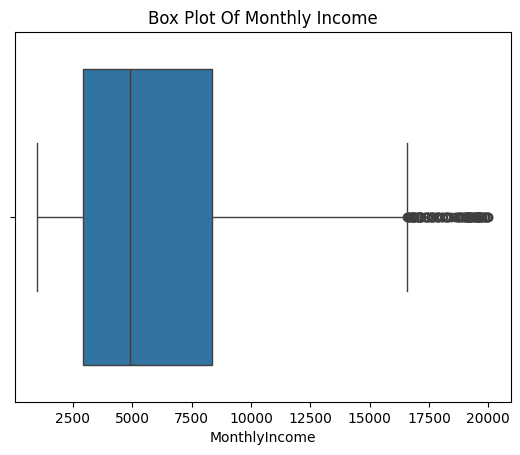

In [27]:
sns.boxplot(x = df['MonthlyIncome'])
plt.title("Box Plot Of Monthly Income")
plt.show()

In [30]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [35]:
df[(lower > df['MonthlyIncome']) | (upper < df['MonthlyIncome'])]

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
547,RM711,33,26-35,No,Non-Travel,722,Sales,17,3,Life Sciences,...,4,80,0,10,2,3,10,8,6,0.0
631,RM1056,34,26-35,No,Travel_Frequently,829,Research & Development,15,3,Medical,...,4,80,2,16,3,2,14,8,6,9.0
917,RM315,39,36-45,No,Travel_Rarely,117,Research & Development,10,1,Medical,...,4,80,0,21,3,3,21,9,11,10.0
918,RM327,39,36-45,No,Travel_Frequently,672,Research & Development,7,2,Medical,...,1,80,1,21,2,3,21,9,13,3.0
920,RM401,39,36-45,No,Travel_Frequently,1218,Research & Development,1,1,Life Sciences,...,3,80,1,21,3,3,21,8,1,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RM596,58,55+,Yes,Travel_Rarely,286,Research & Development,2,4,Life Sciences,...,4,80,0,40,2,3,31,15,13,8.0
1461,RM1010,58,55+,No,Travel_Rarely,1055,Research & Development,1,3,Medical,...,3,80,1,32,3,3,9,8,1,5.0
1464,RM1375,58,55+,No,Travel_Rarely,605,Sales,21,3,Life Sciences,...,3,80,1,29,2,2,1,0,0,0.0
1468,RM106,59,55+,No,Non-Travel,1420,Human Resources,2,4,Human Resources,...,4,80,1,30,3,3,3,2,2,2.0


In [37]:
df_no_outliers = df[(lower <= df['MonthlyIncome']) & (upper >= df['MonthlyIncome'])]
df_no_outliers

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1474,RM920,59,55+,No,Travel_Rarely,1429,Research & Development,18,4,Medical,...,4,80,0,25,6,2,9,7,5,4.0
1476,RM428,60,55+,No,Travel_Frequently,1499,Sales,28,3,Marketing,...,4,80,0,22,5,4,18,13,13,11.0
1477,RM537,60,55+,No,Travel_Rarely,1179,Sales,16,4,Marketing,...,4,80,0,10,1,3,2,2,2,2.0
1478,RM880,60,55+,No,Travel_Rarely,696,Sales,7,4,Marketing,...,2,80,1,12,3,3,11,7,1,9.0


In [40]:
df.corr(numeric_only = True)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000,0.009831,-0.001441,0.207328,NaN,-0.011354,0.009346,0.025559,0.030303,0.509977,...,0.052204,NaN,0.038256,0.680300,-0.018831,-0.021722,0.311535,0.213357,0.216867,0.210786
DailyRate,0.009831,1.000000,-0.004936,-0.016249,NaN,-0.050079,0.018710,0.022450,0.045978,0.002095,...,0.009106,NaN,0.041497,0.014202,0.001544,-0.037684,-0.034384,0.009217,-0.033597,-0.023380
DistanceFromHome,-0.001441,-0.004936,1.000000,0.020427,NaN,0.033703,-0.016472,0.030552,0.011455,0.005338,...,0.006854,NaN,0.045349,0.005834,-0.036918,-0.026341,0.009290,0.018115,0.009566,0.012965
Education,0.207328,-0.016249,0.020427,1.000000,NaN,0.038768,-0.028630,0.018839,0.042461,0.100291,...,-0.007177,NaN,0.017881,0.147879,-0.027329,0.009191,0.069176,0.059486,0.054994,0.069652
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.011354,-0.050079,0.033703,0.038768,NaN,1.000000,0.020571,0.030158,-0.007165,-0.018653,...,-0.069707,NaN,0.061498,-0.014740,0.024955,0.011458,-0.012161,-0.008928,-0.011000,-0.010258
EnvironmentSatisfaction,0.009346,0.018710,-0.016472,-0.028630,NaN,0.020571,1.000000,-0.052249,-0.009575,0.001108,...,0.007382,NaN,0.002922,-0.003436,-0.018430,0.028193,0.001009,0.017995,0.015224,0.003367
HourlyRate,0.025559,0.022450,0.030552,0.018839,NaN,0.030158,-0.052249,1.000000,0.043260,-0.027256,...,0.000941,NaN,0.050867,-0.001739,-0.009266,-0.005552,-0.018679,-0.023408,-0.024982,-0.003692
JobInvolvement,0.030303,0.045978,0.011455,0.042461,NaN,-0.007165,-0.009575,0.043260,1.000000,-0.012590,...,0.034784,NaN,0.022251,-0.003863,-0.015861,-0.014650,-0.021369,0.007847,-0.024226,0.039425
JobLevel,0.509977,0.002095,0.005338,0.100291,NaN,-0.018653,0.001108,-0.027256,-0.012590,1.000000,...,0.019902,NaN,0.014710,0.781761,-0.016780,0.037752,0.534710,0.389918,0.353819,0.373175


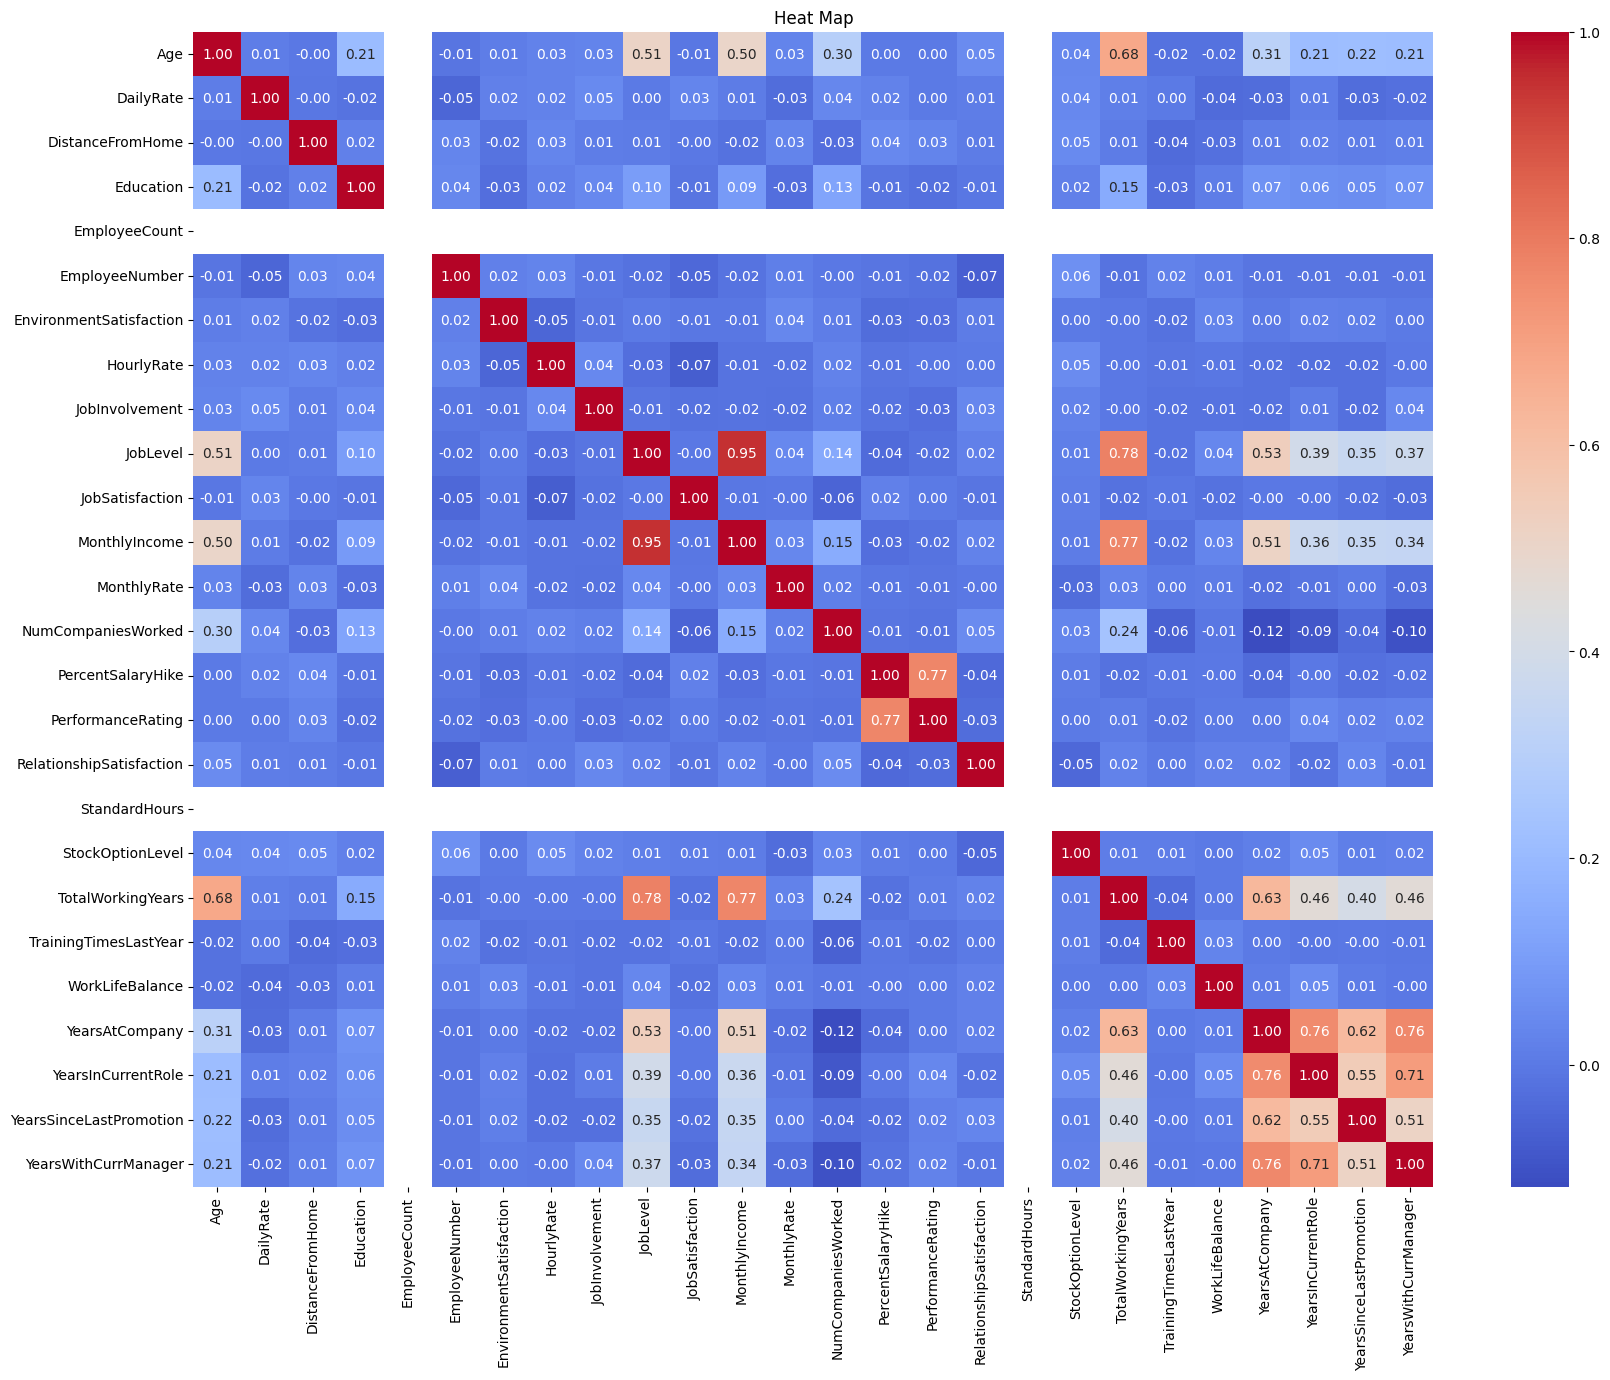

In [51]:
plt.figure(figsize = (20,15))
sns.heatmap(df.corr(numeric_only = True) , annot = True , cmap = 'coolwarm' , fmt='.2f' )
plt.title('Heat Map')
plt.show()

In [53]:
df.corr(numeric_only = True)["MonthlyIncome"].sort_values(ascending = False)

MonthlyIncome               1.000000
JobLevel                    0.950134
TotalWorkingYears           0.771929
YearsAtCompany              0.514343
Age                         0.498078
YearsInCurrentRole          0.364477
YearsSinceLastPromotion     0.345188
YearsWithCurrManager        0.343849
NumCompaniesWorked          0.149853
Education                   0.094285
MonthlyRate                 0.034928
WorkLifeBalance             0.030467
RelationshipSatisfaction    0.024266
DailyRate                   0.006887
StockOptionLevel            0.005863
EnvironmentSatisfaction    -0.006401
JobSatisfaction            -0.008712
HourlyRate                 -0.014751
EmployeeNumber             -0.015758
JobInvolvement             -0.016240
PerformanceRating          -0.016862
DistanceFromHome           -0.017885
TrainingTimesLastYear      -0.020610
PercentSalaryHike          -0.027940
EmployeeCount                    NaN
StandardHours                    NaN
Name: MonthlyIncome, dtype: float64

In [64]:
corr = df.corr(numeric_only = True)["MonthlyIncome"]
corr[corr.abs() > 0.5]

JobLevel             0.950134
MonthlyIncome        1.000000
TotalWorkingYears    0.771929
YearsAtCompany       0.514343
Name: MonthlyIncome, dtype: float64

In [67]:
df['Attrition'].value_counts()['Yes'] / len(df) * 100 

np.float64(16.08961303462322)

In [72]:
df.groupby('Department')['Attrition'].apply(lambda x : (x == "Yes").mean()) * 100

Department
Human Resources           19.047619
Research & Development    13.811007
Sales                     20.581655
Name: Attrition, dtype: float64

In [78]:
(df.groupby('JobRole')['Attrition'].apply(lambda x : (x == "Yes").mean()) * 100).sort_values(ascending = False).head(5)

JobRole
Sales Representative     39.285714
Laboratory Technician    23.846154
Human Resources          23.076923
Sales Executive          17.484663
Research Scientist       16.095890
Name: Attrition, dtype: float64

In [73]:
df.columns

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab',
       'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [84]:
df[df['Attrition'] == "Yes"]['MonthlyIncome'].mean()

np.float64(4787.0928270042195)

In [6]:
df[df['Attrition'] == "Yes"]['Age'].mean()

np.float64(33.6764705882353)

In [10]:
df.groupby('Department')['MonthlyIncome'].mean().sort_values(ascending  = False)

Department
Sales                     6966.737778
Human Resources           6654.507937
Research & Development    6280.365047
Name: MonthlyIncome, dtype: float64

In [12]:
df.groupby('Gender')['MonthlyIncome'].mean().sort_values(ascending = False)

Gender
Female    6684.404399
Male      6385.709786
Name: MonthlyIncome, dtype: float64

In [14]:
df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending  = False).head()

JobRole
Manager                      17181.676471
Research Director            16033.550000
Healthcare Representative     7547.416667
Manufacturing Director        7305.258503
Sales Executive               6947.082067
Name: MonthlyIncome, dtype: float64

In [15]:
df.groupby('Department')['EmpID'].count().sort_values(ascending  =False)

Department
Research & Development    967
Sales                     450
Human Resources            63
Name: EmpID, dtype: int64

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab',
       'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [17]:
df.groupby('Department')["Age"].mean().sort_values(ascending = False)

Department
Human Resources           37.809524
Research & Development    37.015512
Sales                     36.582222
Name: Age, dtype: float64

In [20]:
df['Attrition_number'] = np.where(df['Attrition'] == "Yes" , 1, 0)
df.groupby('Gender')['Attrition_number'].mean().sort_values(ascending = False) * 100 

Gender
Male      16.985377
Female    14.720812
Name: Attrition_number, dtype: float64

In [22]:
df['MonthlyIncome'].mean()

np.float64(6504.985810810811)

In [26]:
df.shape[0]

1480

In [27]:
df['Age'].mean()

np.float64(36.917567567567566)

In [30]:
df.groupby('Age')['MonthlyIncome'].mean().sort_values(ascending = False)

Age
55    13204.181818
50    12637.709677
53    11564.157895
46    11457.969697
54    10875.833333
58    10705.785714
52    10606.888889
60    10268.000000
49     9770.360000
51     9632.473684
48     9344.789474
47     8931.416667
57     8803.000000
43     8444.937500
41     8379.825000
39     8311.886364
56     8248.357143
42     8074.847826
59     8038.100000
45     7811.219512
40     7700.947368
44     7114.333333
37     5853.860000
38     5721.586207
31     5588.400000
36     5547.771429
33     5500.500000
35     5425.282051
34     5258.128205
32     5092.459016
30     4814.850000
29     4572.826087
27     4230.244898
25     4144.769231
28     3904.833333
26     3517.350000
24     3243.923077
22     2950.000000
20     2539.363636
23     2515.357143
21     2491.461538
19     2075.000000
18     1518.375000
Name: MonthlyIncome, dtype: float64

In [31]:
df.groupby('Age')['EmpID'].count().sort_values(ascending = False)

Age
35    78
34    78
31    70
36    70
29    69
32    61
30    60
33    58
38    58
40    57
37    50
27    49
28    48
42    46
39    44
45    41
26    40
41    40
44    33
46    33
43    32
50    31
25    26
24    26
49    25
47    24
55    22
53    19
48    19
51    19
52    18
54    18
22    16
23    14
56    14
58    14
21    13
20    11
59    10
19     9
18     8
60     5
57     4
Name: EmpID, dtype: int64

In [34]:
df.groupby('Age')['Attrition'].apply(lambda x : (x == "Yes").mean() * 100).sort_values(ascending = False).head()

Age
19    66.666667
20    54.545455
18    50.000000
21    46.153846
58    35.714286
Name: Attrition, dtype: float64

In [35]:
df.groupby("Department")['YearsAtCompany'].mean().sort_values(ascending = False).head()

Department
Sales                     7.300000
Human Resources           7.238095
Research & Development    6.859359
Name: YearsAtCompany, dtype: float64

In [37]:
df.groupby("JobRole")['JobSatisfaction'].mean().sort_values(ascending = False).head()

JobRole
Healthcare Representative    2.772727
Research Scientist           2.767918
Sales Executive              2.750760
Sales Representative         2.738095
Manager                      2.705882
Name: JobSatisfaction, dtype: float64

In [38]:
df.groupby('Department')['MonthlyIncome'].mean().sort_values(ascending = False).head()

Department
Sales                     6966.737778
Human Resources           6654.507937
Research & Development    6280.365047
Name: MonthlyIncome, dtype: float64

In [39]:
df.groupby('JobRole')['Attrition'].apply(lambda x : (x == 'Yes').mean() * 100).sort_values(ascending = False).head()

JobRole
Sales Representative     39.285714
Laboratory Technician    23.754789
Human Resources          23.076923
Sales Executive          17.629179
Research Scientist       16.040956
Name: Attrition, dtype: float64

In [40]:
df.groupby('EducationField')['Attrition'].apply(lambda x:(x == "Yes").mean() * 100).sort_values(ascending = False).head()

EducationField
Human Resources     25.925926
Technical Degree    24.242424
Marketing           22.360248
Life Sciences       14.662273
Medical             13.404255
Name: Attrition, dtype: float64

In [41]:
df_leaved = df[df['Attrition'] == "Yes"]
df_leaved.groupby('Department')['MonthlyIncome'].mean().sort_values(ascending = False)

Department
Sales                     5961.634409
Research & Development    4108.075188
Human Resources           3715.750000
Name: MonthlyIncome, dtype: float64

In [43]:
df_10000 = df[df['MonthlyIncome'] > 10000]
df_10000.groupby('Department')['Attrition'].apply(lambda x : (x == "Yes").mean() * 100 ).sort_values(ascending = False).head()

Department
Sales                     17.948718
Human Resources            7.692308
Research & Development     5.729167
Name: Attrition, dtype: float64

In [44]:
df_40 = df[df['Age'] > 40]
df_40.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending = False).head()

JobRole
Manager                      17488.059524
Research Director            17221.320755
Healthcare Representative     8541.730769
Manufacturing Director        8450.434783
Sales Executive               7739.516129
Name: MonthlyIncome, dtype: float64

In [48]:
df[df['Attrition'] == "No"].groupby('EducationField')['YearsAtCompany'].mean().sort_values(ascending = False).head()

EducationField
Human Resources     8.400000
Marketing           8.160000
Medical             7.400491
Life Sciences       7.312741
Technical Degree    6.980000
Name: YearsAtCompany, dtype: float64

In [49]:
df[df['JobSatisfaction'] >= 3].groupby('Department')['PerformanceRating'].mean().sort_values(ascending = False).head()

Department
Human Resources           3.187500
Research & Development    3.152429
Sales                     3.137681
Name: PerformanceRating, dtype: float64

In [50]:
df[df['YearsAtCompany'] < 5].groupby('JobRole')['Attrition'].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending = False).head()

JobRole
Sales Representative     43.478261
Human Resources          37.500000
Laboratory Technician    33.576642
Sales Executive          26.666667
Research Scientist       17.808219
Name: Attrition, dtype: float64

In [52]:
df[(df['Gender'] == 'Male') & (df['Attrition'] == "No")].groupby('Department')['MonthlyIncome'].mean().sort_values(ascending = False).head()

Department
Sales                     7152.299020
Human Resources           6810.513514
Research & Development    6509.879276
Name: MonthlyIncome, dtype: float64

In [56]:
df[df["MonthlyIncome"] > df['MonthlyIncome'].mean()].groupby('EducationField')['Attrition'].apply(lambda x : (x == "Yes").mean() * 100).sort_values(ascending = True).head()

EducationField
Other                4.347826
Medical              8.108108
Life Sciences        9.405941
Technical Degree    11.627907
Human Resources     14.285714
Name: Attrition, dtype: float64

In [62]:
df[(df['Age'] > 35) & (df['JobSatisfaction'] >= 3) & (df['Attrition'] == "No")].groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending = False).head()

JobRole
Manager                      17467.000000
Research Director            16778.564103
Manufacturing Director        8019.660000
Healthcare Representative     7892.301887
Sales Executive               7490.168831
Name: MonthlyIncome, dtype: float64

In [64]:
df[(df["Age"] < 30) & (df["MonthlyIncome"] > 5000) & (df["JobSatisfaction"] <= 2)].groupby('Department')['Attrition'].apply(lambda x : (x == "Yes").mean() * 100).sort_values(ascending = False).head()

Department
Sales                     33.333333
Research & Development     7.692308
Human Resources            0.000000
Name: Attrition, dtype: float64

In [67]:
df[(df["Age"] > 30) & (df["MonthlyIncome"] > df['MonthlyIncome'].median()) &  (df["YearsAtCompany"] >= 5) & (df["JobSatisfaction"] >= 3)].groupby('JobRole')['Attrition'].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending = True).head()

JobRole
Human Resources         0.000000
Research Scientist      0.000000
Sales Representative    0.000000
Research Director       2.941176
Manager                 4.166667
Name: Attrition, dtype: float64

In [70]:
df['EmpID'].count()

np.int64(1480)

In [74]:
df['Attrition'].apply(lambda x: (x == "Yes")).mean() * 100

np.float64(16.08108108108108)

In [75]:
df['MonthlyIncome'].mean()

np.float64(6504.985810810811)

In [76]:
df['Age'].mean()

np.float64(36.917567567567566)

In [77]:
df['YearsAtCompany'].mean()

np.float64(7.0094594594594595)

In [80]:
df[df['Attrition'] == "Yes"].shape[0]

238

In [81]:
df[df['Attrition'] == "No"].shape[0]

1242

In [82]:
df[df['Attrition'] == "Yes"]['MonthlyIncome'].mean()

np.float64(4812.584033613445)

In [83]:
df[df['Attrition'] == "No"]['MonthlyIncome'].mean()

np.float64(6829.294685990338)

In [84]:
df['JobSatisfaction'].mean()

np.float64(2.725)

In [86]:
df['PerformanceRating'].mean()

np.float64(3.1533783783783784)

In [87]:
df['YearsSinceLastPromotion'].mean()

np.float64(2.1824324324324325)

In [88]:
df['DistanceFromHome'].mean()

np.float64(9.22027027027027)

In [89]:
df['WorkLifeBalance'].mean()

np.float64(2.7608108108108107)

In [90]:
df['EnvironmentSatisfaction'].mean()

np.float64(2.7243243243243245)

In [91]:
df['JobInvolvement'].mean()

np.float64(2.72972972972973)

In [93]:
df['PercentSalaryHike'].mean()

np.float64(15.210135135135134)

In [94]:
df['TrainingTimesLastYear'].mean()

np.float64(2.797972972972973)

In [95]:
df['DailyRate'].mean()

np.float64(801.3844594594594)

In [96]:
df['HourlyRate'].mean()

np.float64(65.84527027027028)

In [97]:
df['MonthlyRate'].mean()

np.float64(14298.460810810811)

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab',
       'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'Attrition_number'],
      dtype='object')

In [99]:
df['TotalWorkingYears'].mean()

np.float64(11.281756756756756)

In [101]:
df['NumCompaniesWorked'].mean()

np.float64(2.687162162162162)